In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import graphviz


# 1) Cargar datos
df = pd.read_csv("data/hotel_bookings.csv")

# 2) Mismas features que usaste en KNN (todas numéricas)
features = [
    "lead_time",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]
target = "is_canceled"

data = df[features + [target]].dropna()

X = data[features]
y = data[target]

# 3) Split (sin escalado; los árboles NO lo necesitan)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Árbol de decisión (setup inicial razonable)
dt = DecisionTreeClassifier(
    criterion="gini",      # o "entropy"
    max_depth=6,           # controla complejidad
    min_samples_split=50,  # evita sobreajuste
    min_samples_leaf=20,   # evita hojas con muy pocos casos
    random_state=42
)
dt.fit(X_train, y_train)

# 5) Métricas
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, digits=3))


Accuracy: 0.7472568891866991

Matriz de confusión:
 [[11780  3253]
 [ 2782  6063]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.809     0.784     0.796     15033
           1      0.651     0.685     0.668      8845

    accuracy                          0.747     23878
   macro avg      0.730     0.735     0.732     23878
weighted avg      0.750     0.747     0.749     23878



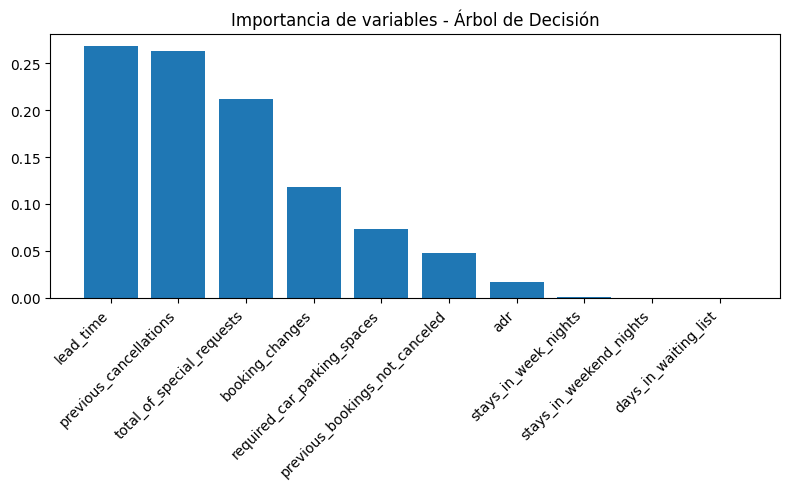

In [12]:
import matplotlib.pyplot as plt
import numpy as np

importances = dt.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(features)), importances[order])
plt.xticks(range(len(features)), [features[i] for i in order], rotation=45, ha="right")
plt.title("Importancia de variables - Árbol de Decisión")
plt.tight_layout()
plt.show()


Precisión del modelo: 0.701

Árbol de decisión (texto):

|--- previous_cancellations <= 0.50
|   |--- lead_time <= 17.50
|   |   |--- lead_time <= 8.50
|   |   |   |--- class: 0
|   |   |--- lead_time >  8.50
|   |   |   |--- class: 0
|   |--- lead_time >  17.50
|   |   |--- total_of_special_requests <= 0.50
|   |   |   |--- class: 1
|   |   |--- total_of_special_requests >  0.50
|   |   |   |--- class: 0
|--- previous_cancellations >  0.50
|   |--- previous_bookings_not_canceled <= 1.50
|   |   |--- lead_time <= 0.50
|   |   |   |--- class: 0
|   |   |--- lead_time >  0.50
|   |   |   |--- class: 1
|   |--- previous_bookings_not_canceled >  1.50
|   |   |--- days_in_waiting_list <= 19.50
|   |   |   |--- class: 0
|   |   |--- days_in_waiting_list >  19.50
|   |   |   |--- class: 1



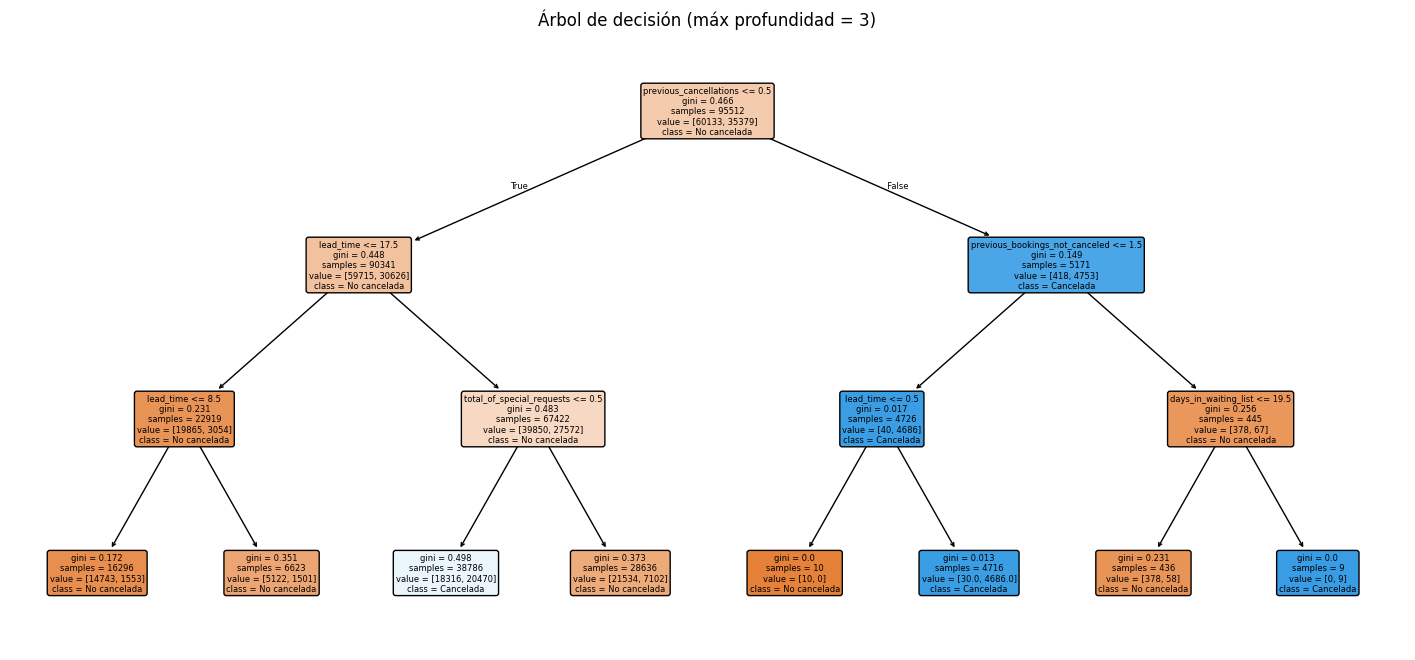

In [15]:
# Entrenamos el árbol con criterio Gini y profundidad 3 (se puede probar entropy o más profundidad)
arbol_decision = tree.DecisionTreeClassifier(
    criterion="gini", 
    max_depth=3,
    random_state=42
)

# Entrenar el modelo con tus datos
arbol = arbol_decision.fit(X_train, y_train)

# Evaluar precisión del modelo
accuracy = arbol_decision.score(X_test, y_test)
print(f"Precisión del modelo: {accuracy:.3f}")

# Mostrar árbol en texto
print("\nÁrbol de decisión (texto):\n")
print(tree.export_text(arbol, feature_names=features))

# Mostrar árbol en formato gráfico
plt.figure(figsize=(18,8))
tree.plot_tree(
    arbol,
    feature_names=features,
    class_names=["No cancelada","Cancelada"],
    filled=True,
    rounded=True
)
plt.title("Árbol de decisión (máx profundidad = 3)")
plt.show()